In [10]:
import torch
print(f"torch verison is {torch.__version__}")


# torch.cuda.empty_cache()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

torch verison is 2.7.1+cu118
cuda


In [11]:
SEED = 42
BATCH_SIZE = 32
HEIGHT = 256
WIDTH = 256

torch shape torch.Size([3, 1317, 1857]) and dtype torch.float32


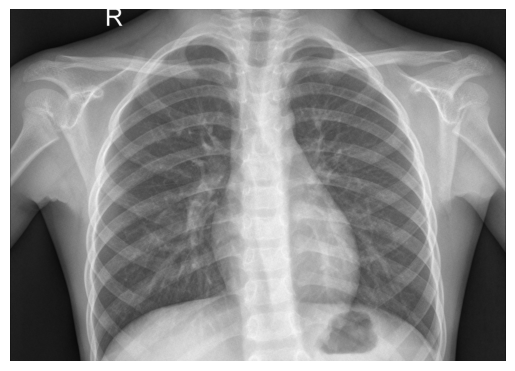

In [12]:
import os
import glob
from PIL import Image

from torchvision import transforms
import matplotlib.pyplot as plt

TRAIN_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray', 'test')

path = glob.glob(os.path.join(TRAIN_DIR, '**', '*.jpeg'), recursive=True)[0]

img_pil = Image.open(path).convert('RGB')
to_tensor = transforms.ToTensor()
img = to_tensor(img_pil)

print(f"torch shape {img.shape} and dtype {img.dtype}")

# visualizing one image
plt.imshow(img.permute(1, 2, 0))  # C,H,W -> H,W,C
plt.axis('off')
plt.show()


In [13]:
train_transformation = transforms.Compose([
    transforms.Resize((HEIGHT, WIDTH)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
])

validation_transform = transforms.Compose(
    [
        transforms.Resize((HEIGHT, WIDTH)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
    ])

from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split

dataset_full = datasets.ImageFolder(root=TRAIN_DIR, transform=None)

train_size = int(0.8 * len(dataset_full))
val_size = len(dataset_full) - train_size
train_dataset, val_dataset = random_split(dataset_full, [train_size, val_size])

train_dataset.dataset.transform = train_transformation
val_dataset.dataset.transform = validation_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"full dataset has images {len(dataset_full)} and classes are {dataset_full.classes} ")
print(f"train dataset has images {len(train_dataset)} and validation dataset has images {len(val_dataset)} ")

images, labels = next(iter(train_loader))
print(f"train_loader images shape is {images.shape} and labels shape is {labels.shape} ")

full dataset has images 624 and classes are ['NORMAL', 'PNEUMONIA'] 
train dataset has images 499 and validation dataset has images 125 
train_loader images shape is torch.Size([32, 1, 256, 256]) and labels shape is torch.Size([32]) 


In [14]:
import torch
import torch.nn as nn

class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # adaptive pooling ensures fixed size regardless of input
        self.pool = nn.AdaptiveAvgPool2d((8, 8))
        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(
            nn.Linear(128*8*8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)  # binary output
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x  # raw logits, no sigmoid

model = PneumoniaCNN().to(DEVICE)
print(model)



from torchsummary import summary
summary(model, input_size=(1, 256, 256))


PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=8192, out_features=

In [15]:
# criterion = nn.BCEWithLogitsLoss()  # recommended for binary classificatio
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_index, (images, labels) in enumerate(train_loader):
        # Move to device
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float().unsqueeze(1)  # [B,1] for BCELoss

        optimizer.zero_grad()

        # Forward pass
        output = model(images)  # raw logits
        output = torch.sigmoid(output)  # convert to probabilities [0,1]

        # Compute loss
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Accuracy
        predicted = (output > 0.5).float()  # threshold at 0.5
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if batch_index % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_index}, Loss: {loss.item():.4f}")

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch 1, Batch 0, Loss: 0.6844
Epoch 1, Batch 10, Loss: 0.3556
Epoch 1/10 - Loss: 0.6917, Accuracy: 73.55%
Epoch 2, Batch 0, Loss: 0.5547
Epoch 2, Batch 10, Loss: 0.2585
Epoch 2/10 - Loss: 0.3919, Accuracy: 82.97%
Epoch 3, Batch 0, Loss: 0.3321
Epoch 3, Batch 10, Loss: 0.2647
Epoch 3/10 - Loss: 0.3111, Accuracy: 86.97%
Epoch 4, Batch 0, Loss: 0.1847
Epoch 4, Batch 10, Loss: 0.2837
Epoch 4/10 - Loss: 0.2779, Accuracy: 88.38%
Epoch 5, Batch 0, Loss: 0.2267
Epoch 5, Batch 10, Loss: 0.1794
Epoch 5/10 - Loss: 0.2226, Accuracy: 91.18%
Epoch 6, Batch 0, Loss: 0.2608
Epoch 6, Batch 10, Loss: 0.2463
Epoch 6/10 - Loss: 0.2318, Accuracy: 90.58%
Epoch 7, Batch 0, Loss: 0.2564
Epoch 7, Batch 10, Loss: 0.1691
Epoch 7/10 - Loss: 0.2096, Accuracy: 92.38%
Epoch 8, Batch 0, Loss: 0.1611
Epoch 8, Batch 10, Loss: 0.0710
Epoch 8/10 - Loss: 0.1778, Accuracy: 93.19%
Epoch 9, Batch 0, Loss: 0.2426
Epoch 9, Batch 10, Loss: 0.1881
Epoch 9/10 - Loss: 0.1931, Accuracy: 91.18%
Epoch 10, Batch 0, Loss: 0.2911
Epoch